In [1]:
!pip install numpy==1.26.4 -q
!pip install nuscenes-devkit pyquaternion -q

In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pyquaternion import Quaternion
from nuscenes.nuscenes import NuScenes
import matplotlib.pyplot as plt

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [4]:
DATA_ROOT = "/content/data/nuscenes"  # Change this to your path
VERSION = "v1.0-mini"

In [5]:
PAST_STEPS = 4      # 2 seconds history (4 × 0.5s)
FUTURE_STEPS = 6    # 3 seconds future (6 × 0.5s)
TRAIN_FRACTION = 0.8

def quaternion_yaw(q):
    """Convert quaternion to yaw angle."""
    q = Quaternion(q)
    return q.yaw_pitch_roll[0]

def global_to_egoframe(xs, ys, yaws):
    """Convert trajectory from global to ego-centric coordinates."""
    x0, y0 = xs[0], ys[0]
    yaw0 = yaws[0]

    xs = xs - x0
    ys = ys - y0

    cos_y = np.cos(-yaw0)
    sin_y = np.sin(-yaw0)

    xr = xs * cos_y - ys * sin_y
    yr = xs * sin_y + ys * cos_y

    return xr, yr

def extract_scene_trajectory(nusc, scene):
    """Extract ego vehicle positions for one scene."""
    traj = []
    sample_token = scene["first_sample_token"]

    while sample_token:
        sample = nusc.get("sample", sample_token)
        lidar_token = sample["data"]["LIDAR_TOP"]
        sd = nusc.get("sample_data", lidar_token)
        ep = nusc.get("ego_pose", sd["ego_pose_token"])

        x, y, z = ep["translation"]
        yaw = quaternion_yaw(ep["rotation"])
        traj.append((x, y, yaw))

        sample_token = sample["next"]

    traj = np.array(traj)
    return traj[:, 0], traj[:, 1], traj[:, 2]

def slice_trajectory(xs, ys):
    """Slice full trajectory into (past, future) windows."""
    past_list, future_list = [], []
    length = len(xs)

    for t in range(PAST_STEPS, length - FUTURE_STEPS):
        past = np.stack([xs[t-PAST_STEPS:t], ys[t-PAST_STEPS:t]], axis=1)
        future = np.stack([xs[t:t+FUTURE_STEPS], ys[t:t+FUTURE_STEPS]], axis=1)
        past_list.append(past)
        future_list.append(future)

    return past_list, future_list

def extract_and_save_data(data_root, version, save_dir="./data"):
    """Main function to extract trajectory data from nuScenes."""
    os.makedirs(save_dir, exist_ok=True)

    print("Loading nuScenes...")
    nusc = NuScenes(version=version, dataroot=data_root, verbose=True)

    all_past, all_future = [], []
    scenes = nusc.scene
    print(f"Found {len(scenes)} scenes.")

    for idx, scene in enumerate(scenes):
        print(f"Processing scene {idx+1}/{len(scenes)}...")
        xs, ys, yaws = extract_scene_trajectory(nusc, scene)
        xs, ys = global_to_egoframe(xs, ys, yaws)
        past_list, future_list = slice_trajectory(xs, ys)
        all_past.extend(past_list)
        all_future.extend(future_list)

    all_past = np.array(all_past)
    all_future = np.array(all_future)

    print(f"\nTotal samples: {len(all_past)}")
    print(f"Past shape: {all_past.shape}")
    print(f"Future shape: {all_future.shape}")

    # Train/val split
    total = len(all_past)
    train_size = int(TRAIN_FRACTION * total)

    np.save(os.path.join(save_dir, "train_past.npy"), all_past[:train_size])
    np.save(os.path.join(save_dir, "train_future.npy"), all_future[:train_size])
    np.save(os.path.join(save_dir, "val_past.npy"), all_past[train_size:])
    np.save(os.path.join(save_dir, "val_future.npy"), all_future[train_size:])

    print(f"\nData saved to {save_dir}/")
    print(f"  Train samples: {train_size}")
    print(f"  Val samples: {total - train_size}")

    return nusc

In [6]:
nusc = extract_and_save_data(DATA_ROOT, VERSION, save_dir="./data")

Loading nuScenes...
Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.387 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.
Found 10 scenes.
Processing scene 1/10...
Processing scene 2/10...
Processing scene 3/10...
Processing scene 4/10...
Processing scene 5/10...
Processing scene 6/10...
Processing scene 7/10...
Processing scene 8/10...
Processing scene 9/10...
Processing scene 10/10...

Total samples: 304
Past shape: (304, 4, 2)
Future shape: (304, 6, 2)

Data saved to ./data/
  Train samples: 243
  Val samples: 61


In [7]:
class ImprovedTrajectoryDataset(Dataset):
    """
    Improvements:
    1. Add velocity features (vx, vy)
    2. Add acceleration features (ax, ay)
    3. Return last position for residual prediction
    """
    def __init__(self, root_dir, split="train"):
        self.past = np.load(f"{root_dir}/{split}_past.npy")
        self.future = np.load(f"{root_dir}/{split}_future.npy")
        print(f"Loaded {split} set: {len(self.past)} samples")

    def __len__(self):
        return len(self.past)

    def __getitem__(self, idx):
        past = self.past[idx]      # (4, 2)
        future = self.future[idx]  # (6, 2)

        # Compute velocity (displacement between frames)
        velocity = np.zeros_like(past)
        velocity[1:] = past[1:] - past[:-1]

        # Compute acceleration (change in velocity)
        acceleration = np.zeros_like(past)
        acceleration[2:] = velocity[2:] - velocity[1:-1]

        # Concatenate: (x, y, vx, vy, ax, ay) -> (4, 6)
        past_features = np.concatenate([past, velocity, acceleration], axis=1)

        # Last known position for residual prediction
        last_pos = past[-1]

        # Last known velocity for motion prior
        last_vel = velocity[-1]

        return (
            torch.tensor(past_features, dtype=torch.float32),
            torch.tensor(last_pos, dtype=torch.float32),
            torch.tensor(last_vel, dtype=torch.float32),
            torch.tensor(future, dtype=torch.float32)
        )

In [8]:
class ImprovedLSTMModel(nn.Module):
    """
    Improvements over baseline:
    1. Richer input features (pos + vel + acc)
    2. Larger hidden dimension
    3. Bidirectional LSTM option
    4. Dropout regularization
    5. Residual prediction (predict displacement, not absolute position)
    6. MLP decoder instead of single linear layer
    """
    def __init__(
        self,
        input_dim=6,        # (x, y, vx, vy, ax, ay)
        hidden_dim=128,
        num_layers=2,
        future_steps=6,
        dropout=0.2,
        bidirectional=True
    ):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.future_steps = future_steps
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1

        # LSTM encoder
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )

        # MLP decoder
        lstm_output_dim = hidden_dim * self.num_directions
        self.decoder = nn.Sequential(
            nn.Linear(lstm_output_dim + 2, hidden_dim),  # +2 for last velocity
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, future_steps * 2)
        )

    def forward(self, past_features, last_pos, last_vel):
        """
        Args:
            past_features: (B, past_steps, 6) - position + velocity + acceleration
            last_pos: (B, 2) - last known position
            last_vel: (B, 2) - last known velocity
        Returns:
            future: (B, future_steps, 2) - predicted positions
        """
        batch_size = past_features.size(0)

        # Encode past trajectory
        _, (h_n, _) = self.lstm(past_features)

        # Get final hidden state
        if self.bidirectional:
            # Concatenate forward and backward final states
            h_final = torch.cat([h_n[-2], h_n[-1]], dim=1)
        else:
            h_final = h_n[-1]

        # Concatenate with last velocity (motion prior)
        decoder_input = torch.cat([h_final, last_vel], dim=1)

        # Predict displacements
        displacement_flat = self.decoder(decoder_input)
        displacement = displacement_flat.view(batch_size, self.future_steps, 2)

        # Cumulative sum to get positions (residual prediction)
        future = last_pos.unsqueeze(1) + torch.cumsum(displacement, dim=1)

        return future

In [9]:
def train_model(
    data_dir="./data",
    epochs=200,
    batch_size=32,
    learning_rate=1e-3,
    weight_decay=1e-4,
    save_path="./model_improved.pt"
):
    # Load datasets
    train_dataset = ImprovedTrajectoryDataset(data_dir, split="train")
    val_dataset = ImprovedTrajectoryDataset(data_dir, split="val")

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Model, optimizer, scheduler
    model = ImprovedLSTMModel().to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.SmoothL1Loss()  # More robust than MSE

    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
    print(f"Training on {DEVICE}")

    # Training history
    history = {"train_loss": [], "val_loss": [], "val_ade": [], "val_fde": []}
    best_val_loss = float("inf")

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for past_feat, last_pos, last_vel, future in train_loader:
            past_feat = past_feat.to(DEVICE)
            last_pos = last_pos.to(DEVICE)
            last_vel = last_vel.to(DEVICE)
            future = future.to(DEVICE)

            pred = model(past_feat, last_pos, last_vel)
            loss = criterion(pred, future)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item()

        scheduler.step()
        avg_train_loss = train_loss / len(train_loader)

        # Validation
        model.eval()
        val_loss, total_ade, total_fde, count = 0, 0, 0, 0

        with torch.no_grad():
            for past_feat, last_pos, last_vel, future in val_loader:
                past_feat = past_feat.to(DEVICE)
                last_pos = last_pos.to(DEVICE)
                last_vel = last_vel.to(DEVICE)
                future = future.to(DEVICE)

                pred = model(past_feat, last_pos, last_vel)
                loss = criterion(pred, future)
                val_loss += loss.item()

                # ADE & FDE
                ade = torch.norm(pred - future, dim=2).mean().item()
                fde = torch.norm(pred[:, -1] - future[:, -1], dim=1).mean().item()
                total_ade += ade * len(past_feat)
                total_fde += fde * len(past_feat)
                count += len(past_feat)

        avg_val_loss = val_loss / len(val_loader)
        avg_ade = total_ade / count
        avg_fde = total_fde / count

        # Save history
        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["val_ade"].append(avg_ade)
        history["val_fde"].append(avg_fde)

        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), save_path)

        # Print progress
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | "
                  f"Train: {avg_train_loss:.4f} | "
                  f"Val: {avg_val_loss:.4f} | "
                  f"ADE: {avg_ade:.4f}m | "
                  f"FDE: {avg_fde:.4f}m")

    print(f"\nBest model saved to {save_path}")
    return model, history


In [10]:
model, history = train_model(epochs=200)

Loaded train set: 243 samples
Loaded val set: 61 samples
Model parameters: 585,740
Training on cuda
Epoch   1/200 | Train: 5.7496 | Val: 3.0057 | ADE: 5.9222m | FDE: 10.5832m
Epoch  10/200 | Train: 1.2833 | Val: 1.4695 | ADE: 3.1198m | FDE: 5.5453m
Epoch  20/200 | Train: 0.6820 | Val: 1.6019 | ADE: 3.5230m | FDE: 6.1969m
Epoch  30/200 | Train: 0.6783 | Val: 1.4383 | ADE: 3.2289m | FDE: 5.7131m
Epoch  40/200 | Train: 0.5640 | Val: 1.2766 | ADE: 2.8240m | FDE: 5.0300m
Epoch  50/200 | Train: 0.6587 | Val: 1.3850 | ADE: 2.8808m | FDE: 5.0248m
Epoch  60/200 | Train: 0.5137 | Val: 1.4272 | ADE: 3.0734m | FDE: 5.4238m
Epoch  70/200 | Train: 0.4917 | Val: 1.4353 | ADE: 3.1729m | FDE: 5.6018m
Epoch  80/200 | Train: 0.4950 | Val: 1.4023 | ADE: 3.1222m | FDE: 5.5084m
Epoch  90/200 | Train: 0.4658 | Val: 1.3951 | ADE: 2.9867m | FDE: 5.2805m
Epoch 100/200 | Train: 0.4664 | Val: 1.3170 | ADE: 2.8153m | FDE: 5.0186m
Epoch 110/200 | Train: 0.4990 | Val: 1.2414 | ADE: 2.7306m | FDE: 4.8500m
Epoch 120/2

In [11]:
def plot_training_history(history):
    """Plot training curves."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Loss
    axes[0].plot(history["train_loss"], label="Train")
    axes[0].plot(history["val_loss"], label="Val")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Training & Validation Loss")
    axes[0].legend()
    axes[0].grid(True)

    # ADE
    axes[1].plot(history["val_ade"], color="orange")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("ADE (meters)")
    axes[1].set_title("Average Displacement Error")
    axes[1].grid(True)

    # FDE
    axes[2].plot(history["val_fde"], color="green")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("FDE (meters)")
    axes[2].set_title("Final Displacement Error")
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

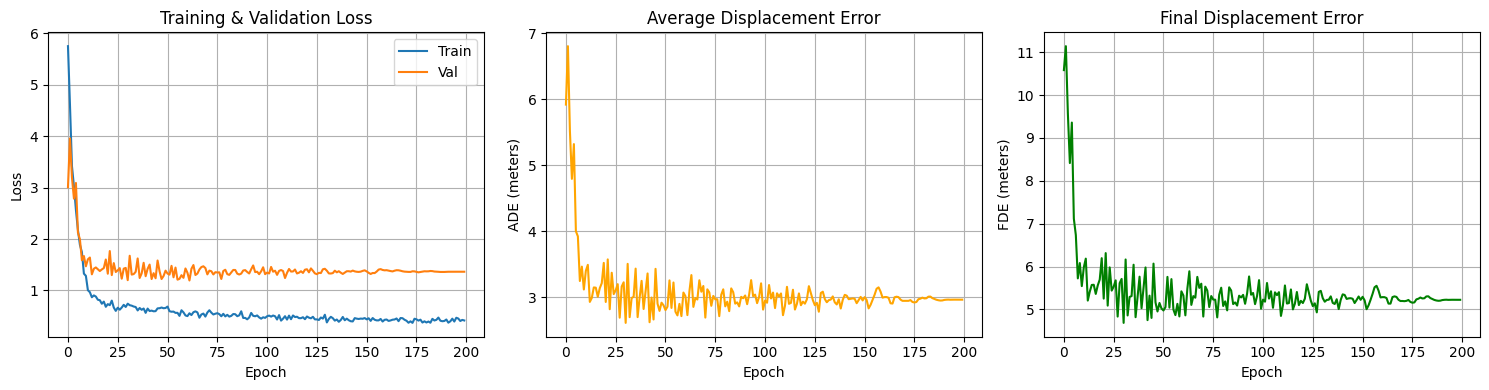

In [12]:
plot_training_history(history)

In [13]:
def visualize_predictions(model, dataset, num_samples=6):
    """Visualize predicted vs ground truth trajectories."""
    model.eval()
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    indices = np.random.choice(len(dataset), num_samples, replace=False)

    for i, idx in enumerate(indices):
        past_feat, last_pos, last_vel, future = dataset[idx]
        past_feat = past_feat.unsqueeze(0).to(DEVICE)
        last_pos_t = last_pos.unsqueeze(0).to(DEVICE)
        last_vel_t = last_vel.unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            pred = model(past_feat, last_pos_t, last_vel_t)

        # Extract position from features
        past_pos = past_feat[0, :, :2].cpu().numpy()
        pred = pred[0].cpu().numpy()
        future = future.numpy()

        ax = axes[i]
        ax.plot(past_pos[:, 0], past_pos[:, 1], "b.-", label="Past", markersize=10)
        ax.plot(future[:, 0], future[:, 1], "g.-", label="Ground Truth", markersize=10)
        ax.plot(pred[:, 0], pred[:, 1], "r.--", label="Predicted", markersize=10)

        # Mark start and end
        ax.scatter(past_pos[0, 0], past_pos[0, 1], c="blue", s=100, marker="s", zorder=5)
        ax.scatter(future[-1, 0], future[-1, 1], c="green", s=100, marker="*", zorder=5)
        ax.scatter(pred[-1, 0], pred[-1, 1], c="red", s=100, marker="*", zorder=5)

        ax.set_xlabel("X (m)")
        ax.set_ylabel("Y (m)")
        ax.set_title(f"Sample {idx}")
        ax.legend(loc="best")
        ax.grid(True)
        ax.axis("equal")

    plt.tight_layout()
    plt.show()

Loaded val set: 61 samples


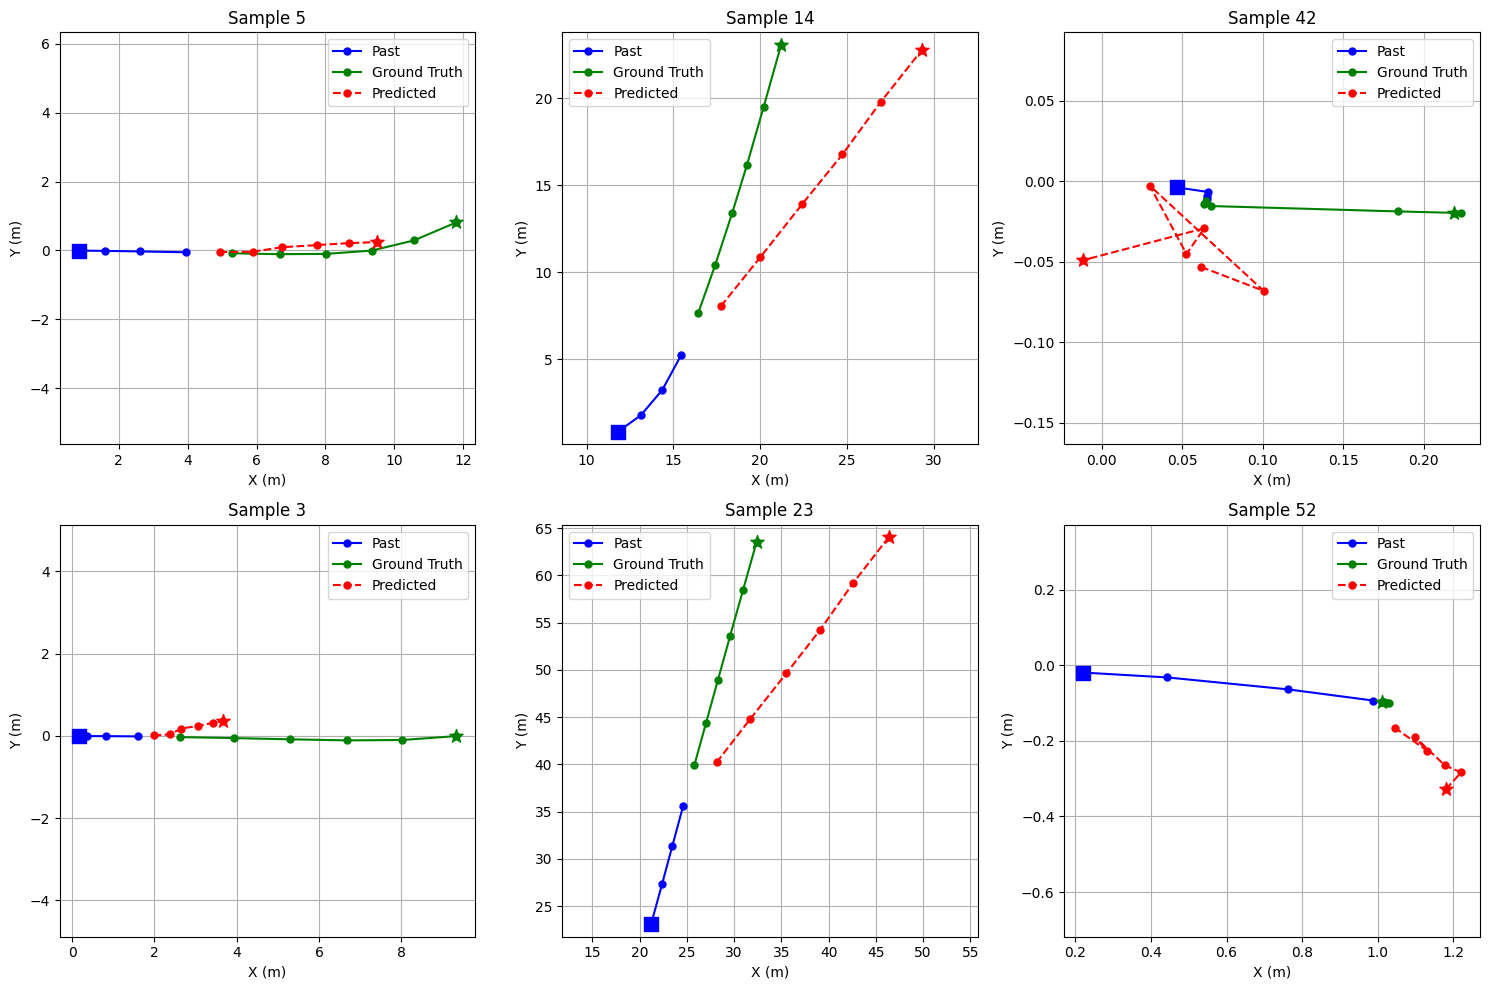

In [14]:
val_dataset = ImprovedTrajectoryDataset("./data", split="val")
model.load_state_dict(torch.load("./model_improved.pt"))
visualize_predictions(model, val_dataset)

In [15]:
def evaluate_model(model, data_dir="./data"):
    """Final evaluation on validation set."""
    val_dataset = ImprovedTrajectoryDataset(data_dir, split="val")
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

    model.eval()
    total_ade, total_fde, count = 0, 0, 0

    with torch.no_grad():
        for past_feat, last_pos, last_vel, future in val_loader:
            past_feat = past_feat.to(DEVICE)
            last_pos = last_pos.to(DEVICE)
            last_vel = last_vel.to(DEVICE)
            future = future.to(DEVICE)

            pred = model(past_feat, last_pos, last_vel)

            ade = torch.norm(pred - future, dim=2).mean().item()
            fde = torch.norm(pred[:, -1] - future[:, -1], dim=1).mean().item()

            total_ade += ade * len(past_feat)
            total_fde += fde * len(past_feat)
            count += len(past_feat)

    final_ade = total_ade / count
    final_fde = total_fde / count

    print("=" * 50)
    print("  Improved LSTM - Final Evaluation Results")
    print("=" * 50)
    print(f"  ADE: {final_ade:.4f} meters")
    print(f"  FDE: {final_fde:.4f} meters")
    print("=" * 50)

    return final_ade, final_fde

In [16]:
model.load_state_dict(torch.load("./model_improved.pt"))
ade, fde = evaluate_model(model)

Loaded val set: 61 samples
  Improved LSTM - Final Evaluation Results
  ADE: 2.7315 meters
  FDE: 4.8633 meters


In [17]:
def visualize_best_worst_predictions(model, dataset, num_each=3):
    """Visualize best and worst predictions based on ADE."""
    model.eval()
    errors = []

    # Calculate ADE for all samples
    with torch.no_grad():
        for idx in range(len(dataset)):
            past_feat, last_pos, last_vel, future = dataset[idx]
            past_feat = past_feat.unsqueeze(0).to(DEVICE)
            last_pos_t = last_pos.unsqueeze(0).to(DEVICE)
            last_vel_t = last_vel.unsqueeze(0).to(DEVICE)

            pred = model(past_feat, last_pos_t, last_vel_t)
            ade = torch.norm(pred[0].cpu() - future, dim=1).mean().item()
            errors.append((idx, ade))

    # Sort by error
    errors.sort(key=lambda x: x[1])
    best_indices = [e[0] for e in errors[:num_each]]
    worst_indices = [e[0] for e in errors[-num_each:]]

    fig, axes = plt.subplots(2, num_each, figsize=(5*num_each, 10))

    for col, idx in enumerate(best_indices):
        past_feat, last_pos, last_vel, future = dataset[idx]
        past_feat_t = past_feat.unsqueeze(0).to(DEVICE)
        last_pos_t = last_pos.unsqueeze(0).to(DEVICE)
        last_vel_t = last_vel.unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            pred = model(past_feat_t, last_pos_t, last_vel_t)[0].cpu().numpy()

        past_pos = past_feat[:, :2].numpy()
        future_np = future.numpy()
        ade = errors[col][1]

        ax = axes[0, col]
        ax.plot(past_pos[:, 0], past_pos[:, 1], 'b.-', lw=2, ms=8, label='Past')
        ax.plot(future_np[:, 0], future_np[:, 1], 'g.-', lw=2, ms=8, label='GT')
        ax.plot(pred[:, 0], pred[:, 1], 'r.--', lw=2, ms=8, label='Pred')
        ax.set_title(f'Best #{col+1} (ADE={ade:.3f}m)', fontsize=12)
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.axis('equal')

    for col, idx in enumerate(worst_indices):
        past_feat, last_pos, last_vel, future = dataset[idx]
        past_feat_t = past_feat.unsqueeze(0).to(DEVICE)
        last_pos_t = last_pos.unsqueeze(0).to(DEVICE)
        last_vel_t = last_vel.unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            pred = model(past_feat_t, last_pos_t, last_vel_t)[0].cpu().numpy()

        past_pos = past_feat[:, :2].numpy()
        future_np = future.numpy()
        ade_val = errors[-(num_each-col)][1]

        ax = axes[1, col]
        ax.plot(past_pos[:, 0], past_pos[:, 1], 'b.-', lw=2, ms=8, label='Past')
        ax.plot(future_np[:, 0], future_np[:, 1], 'g.-', lw=2, ms=8, label='GT')
        ax.plot(pred[:, 0], pred[:, 1], 'r.--', lw=2, ms=8, label='Pred')
        ax.set_title(f'Worst #{col+1} (ADE={ade_val:.3f}m)', fontsize=12)
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.axis('equal')

    axes[0, 0].set_ylabel('Best Predictions', fontsize=14)
    axes[1, 0].set_ylabel('Worst Predictions', fontsize=14)
    plt.suptitle('Best vs Worst Trajectory Predictions', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

    return errors

Visualizing Best and Worst Predictions...
Loaded val set: 61 samples


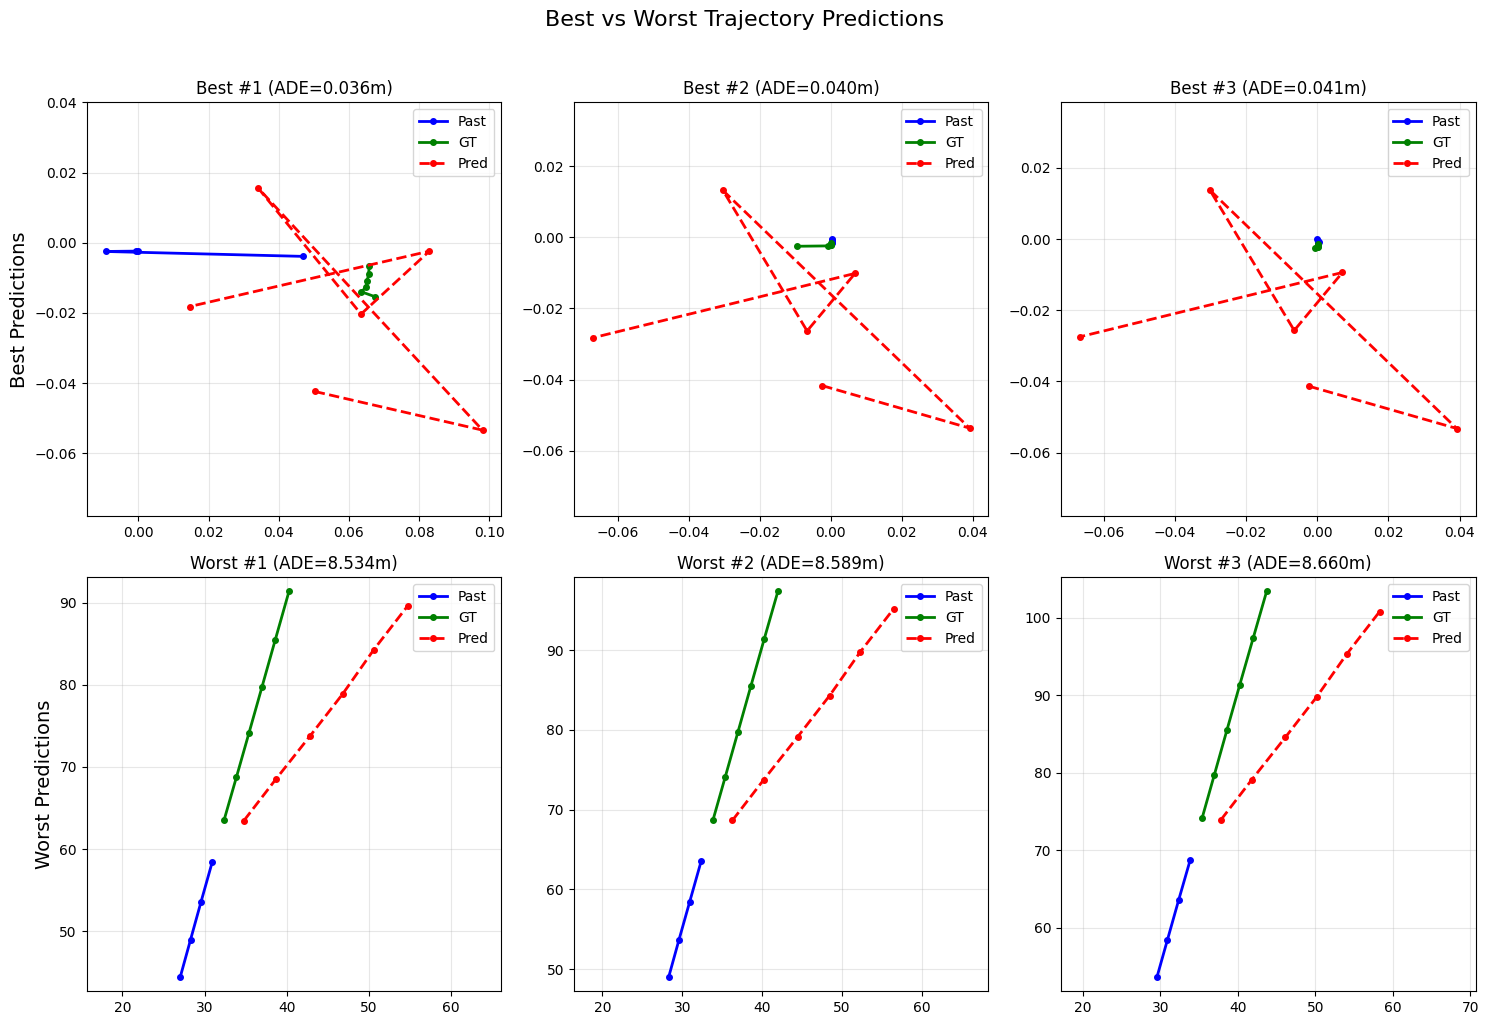

In [18]:
print("Visualizing Best and Worst Predictions...")
val_dataset = ImprovedTrajectoryDataset("./data", split="val")
model.load_state_dict(torch.load("./model_improved.pt"))
all_errors = visualize_best_worst_predictions(model, val_dataset)

In [19]:
def plot_error_distribution(errors):
    """Plot error distribution histogram."""
    ade_values = [e[1] for e in errors]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram
    ax1 = axes[0]
    n, bins, patches = ax1.hist(ade_values, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    ax1.axvline(np.mean(ade_values), color='red', linestyle='--', lw=2, label=f'Mean: {np.mean(ade_values):.3f}m')
    ax1.axvline(np.median(ade_values), color='orange', linestyle='--', lw=2, label=f'Median: {np.median(ade_values):.3f}m')
    ax1.set_xlabel('ADE (meters)', fontsize=12)
    ax1.set_ylabel('Count', fontsize=12)
    ax1.set_title('ADE Distribution', fontsize=14)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Cumulative distribution
    ax2 = axes[1]
    sorted_ade = np.sort(ade_values)
    cumulative = np.arange(1, len(sorted_ade) + 1) / len(sorted_ade)
    ax2.plot(sorted_ade, cumulative, 'b-', lw=2)
    ax2.axhline(0.5, color='gray', linestyle=':', alpha=0.7)
    ax2.axhline(0.9, color='gray', linestyle=':', alpha=0.7)

    # Find percentile values
    p50 = np.percentile(ade_values, 50)
    p90 = np.percentile(ade_values, 90)
    ax2.axvline(p50, color='orange', linestyle='--', label=f'50th: {p50:.3f}m')
    ax2.axvline(p90, color='red', linestyle='--', label=f'90th: {p90:.3f}m')

    ax2.set_xlabel('ADE (meters)', fontsize=12)
    ax2.set_ylabel('Cumulative Probability', fontsize=12)
    ax2.set_title('Cumulative ADE Distribution', fontsize=14)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print statistics
    print("\n Error Statistics:")
    print(f"  Mean ADE:   {np.mean(ade_values):.4f} m")
    print(f"  Std ADE:    {np.std(ade_values):.4f} m")
    print(f"  Median ADE: {np.median(ade_values):.4f} m")
    print(f"  Min ADE:    {np.min(ade_values):.4f} m")
    print(f"  Max ADE:    {np.max(ade_values):.4f} m")
    print(f"  90th Percentile: {p90:.4f} m")

Plotting Error Distribution...


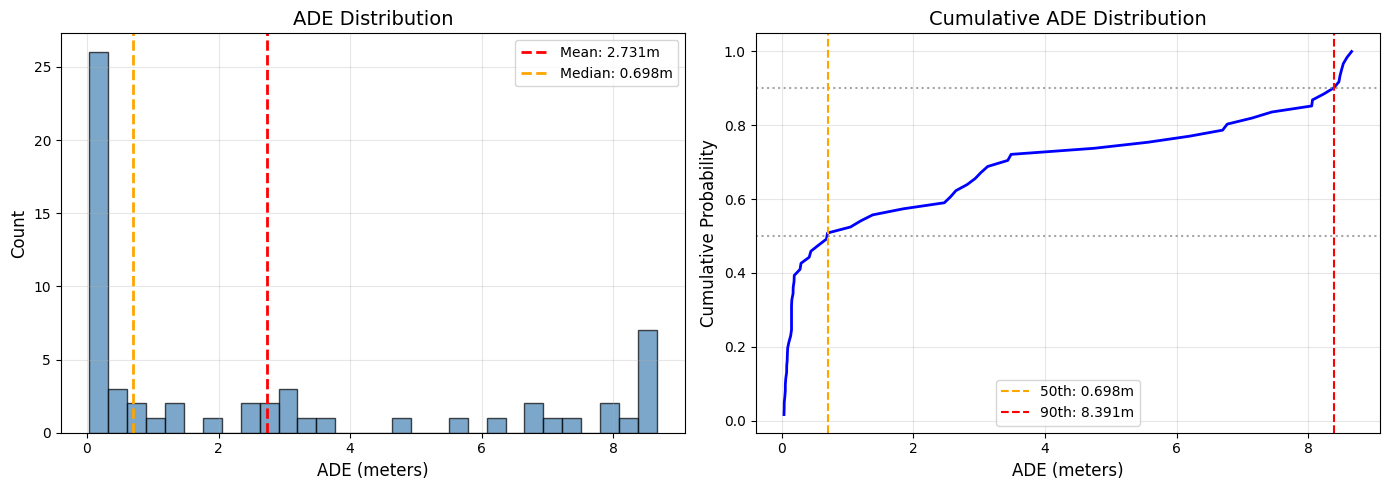


 Error Statistics:
  Mean ADE:   2.7315 m
  Std ADE:    3.2118 m
  Median ADE: 0.6979 m
  Min ADE:    0.0364 m
  Max ADE:    8.6603 m
  90th Percentile: 8.3908 m


In [20]:
print("Plotting Error Distribution...")
plot_error_distribution(all_errors)

In [22]:
def plot_timestep_errors(model, dataset):
    """Plot error at each prediction timestep."""
    model.eval()
    num_steps = 6  # FUTURE_STEPS
    step_errors = [[] for _ in range(num_steps)]

    with torch.no_grad():
        for idx in range(len(dataset)):
            past_feat, last_pos, last_vel, future = dataset[idx]
            past_feat = past_feat.unsqueeze(0).to(DEVICE)
            last_pos_t = last_pos.unsqueeze(0).to(DEVICE)
            last_vel_t = last_vel.unsqueeze(0).to(DEVICE)

            pred = model(past_feat, last_pos_t, last_vel_t)[0].cpu()

            for t in range(num_steps):
                err = torch.norm(pred[t] - future[t]).item()
                step_errors[t].append(err)

    # Calculate statistics
    means = [np.mean(errs) for errs in step_errors]
    stds = [np.std(errs) for errs in step_errors]
    time_steps = [0.5 * (t + 1) for t in range(num_steps)]  # 0.5s intervals

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Line plot with error bars
    ax1 = axes[0]
    ax1.errorbar(time_steps, means, yerr=stds, fmt='o-', capsize=5, capthick=2,
                 color='steelblue', ecolor='lightcoral', lw=2, ms=8)
    ax1.fill_between(time_steps,
                     np.array(means) - np.array(stds),
                     np.array(means) + np.array(stds),
                     alpha=0.2, color='steelblue')
    ax1.set_xlabel('Prediction Horizon (seconds)', fontsize=12)
    ax1.set_ylabel('Displacement Error (meters)', fontsize=12)
    ax1.set_title('Error vs Prediction Horizon', fontsize=14)
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(time_steps)

    # Box plot
    ax2 = axes[1]
    bp = ax2.boxplot(step_errors, positions=time_steps, widths=0.15, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightsteelblue')
    ax2.set_xlabel('Prediction Horizon (seconds)', fontsize=12)
    ax2.set_ylabel('Displacement Error (meters)', fontsize=12)
    ax2.set_title('Error Distribution per Timestep', fontsize=14)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n Per-Timestep Error:")
    for t, (m, s) in enumerate(zip(means, stds)):
        print(f"  t={time_steps[t]:.1f}s: {m:.4f} ± {s:.4f} m")

 Analyzing Per-Timestep Errors...


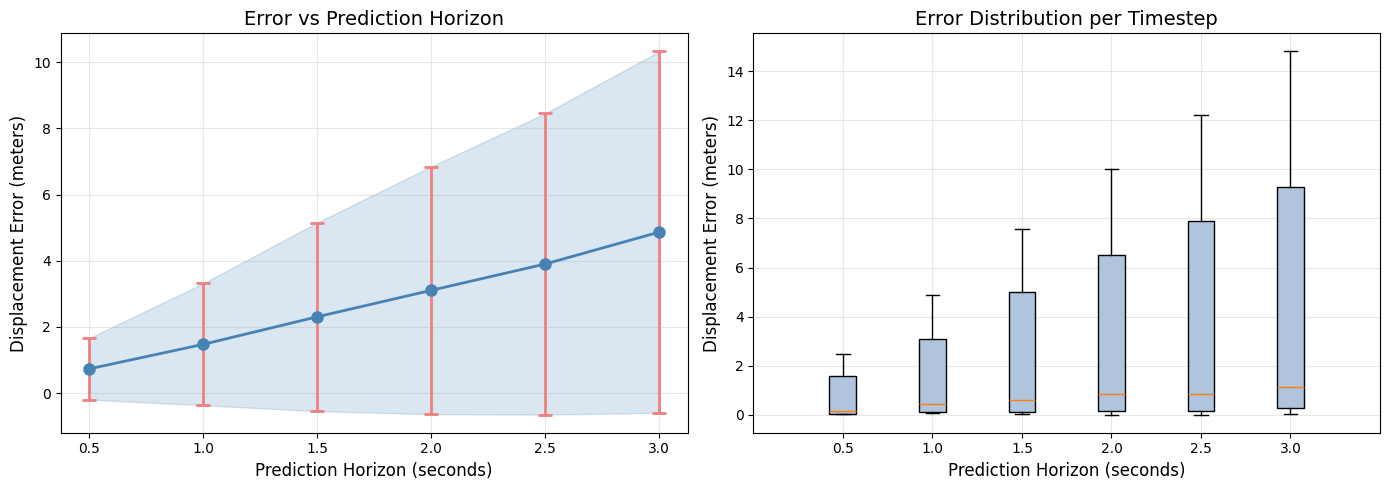


 Per-Timestep Error:
  t=0.5s: 0.7357 ± 0.9305 m
  t=1.0s: 1.4759 ± 1.8405 m
  t=1.5s: 2.3071 ± 2.8478 m
  t=2.0s: 3.1059 ± 3.7401 m
  t=2.5s: 3.9009 ± 4.5464 m
  t=3.0s: 4.8633 ± 5.4560 m


In [23]:
print(" Analyzing Per-Timestep Errors...")
plot_timestep_errors(model, val_dataset)

In [24]:
def plot_trajectory_grid(model, dataset, grid_size=4):
    """Plot a grid of random trajectory predictions."""
    model.eval()
    num_samples = grid_size * grid_size
    indices = np.random.choice(len(dataset), num_samples, replace=False)

    fig, axes = plt.subplots(grid_size, grid_size, figsize=(4*grid_size, 4*grid_size))

    for i, idx in enumerate(indices):
        row, col = i // grid_size, i % grid_size
        ax = axes[row, col]

        past_feat, last_pos, last_vel, future = dataset[idx]
        past_feat_t = past_feat.unsqueeze(0).to(DEVICE)
        last_pos_t = last_pos.unsqueeze(0).to(DEVICE)
        last_vel_t = last_vel.unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            pred = model(past_feat_t, last_pos_t, last_vel_t)[0].cpu().numpy()

        past_pos = past_feat[:, :2].numpy()
        future_np = future.numpy()

        # Calculate ADE for this sample
        ade = np.mean(np.linalg.norm(pred - future_np, axis=1))

        # Plot
        ax.plot(past_pos[:, 0], past_pos[:, 1], 'b.-', lw=1.5, ms=6, label='Past')
        ax.plot(future_np[:, 0], future_np[:, 1], 'g.-', lw=1.5, ms=6, label='GT')
        ax.plot(pred[:, 0], pred[:, 1], 'r.--', lw=1.5, ms=6, label='Pred')

        # Connect last past point to first future point
        ax.plot([past_pos[-1, 0], future_np[0, 0]],
                [past_pos[-1, 1], future_np[0, 1]], 'g-', lw=1, alpha=0.5)
        ax.plot([past_pos[-1, 0], pred[0, 0]],
                [past_pos[-1, 1], pred[0, 1]], 'r--', lw=1, alpha=0.5)

        ax.set_title(f'ADE: {ade:.3f}m', fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.axis('equal')

        if i == 0:
            ax.legend(fontsize=8)

    plt.suptitle('Trajectory Prediction Samples', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()

 Plotting Trajectory Grid...


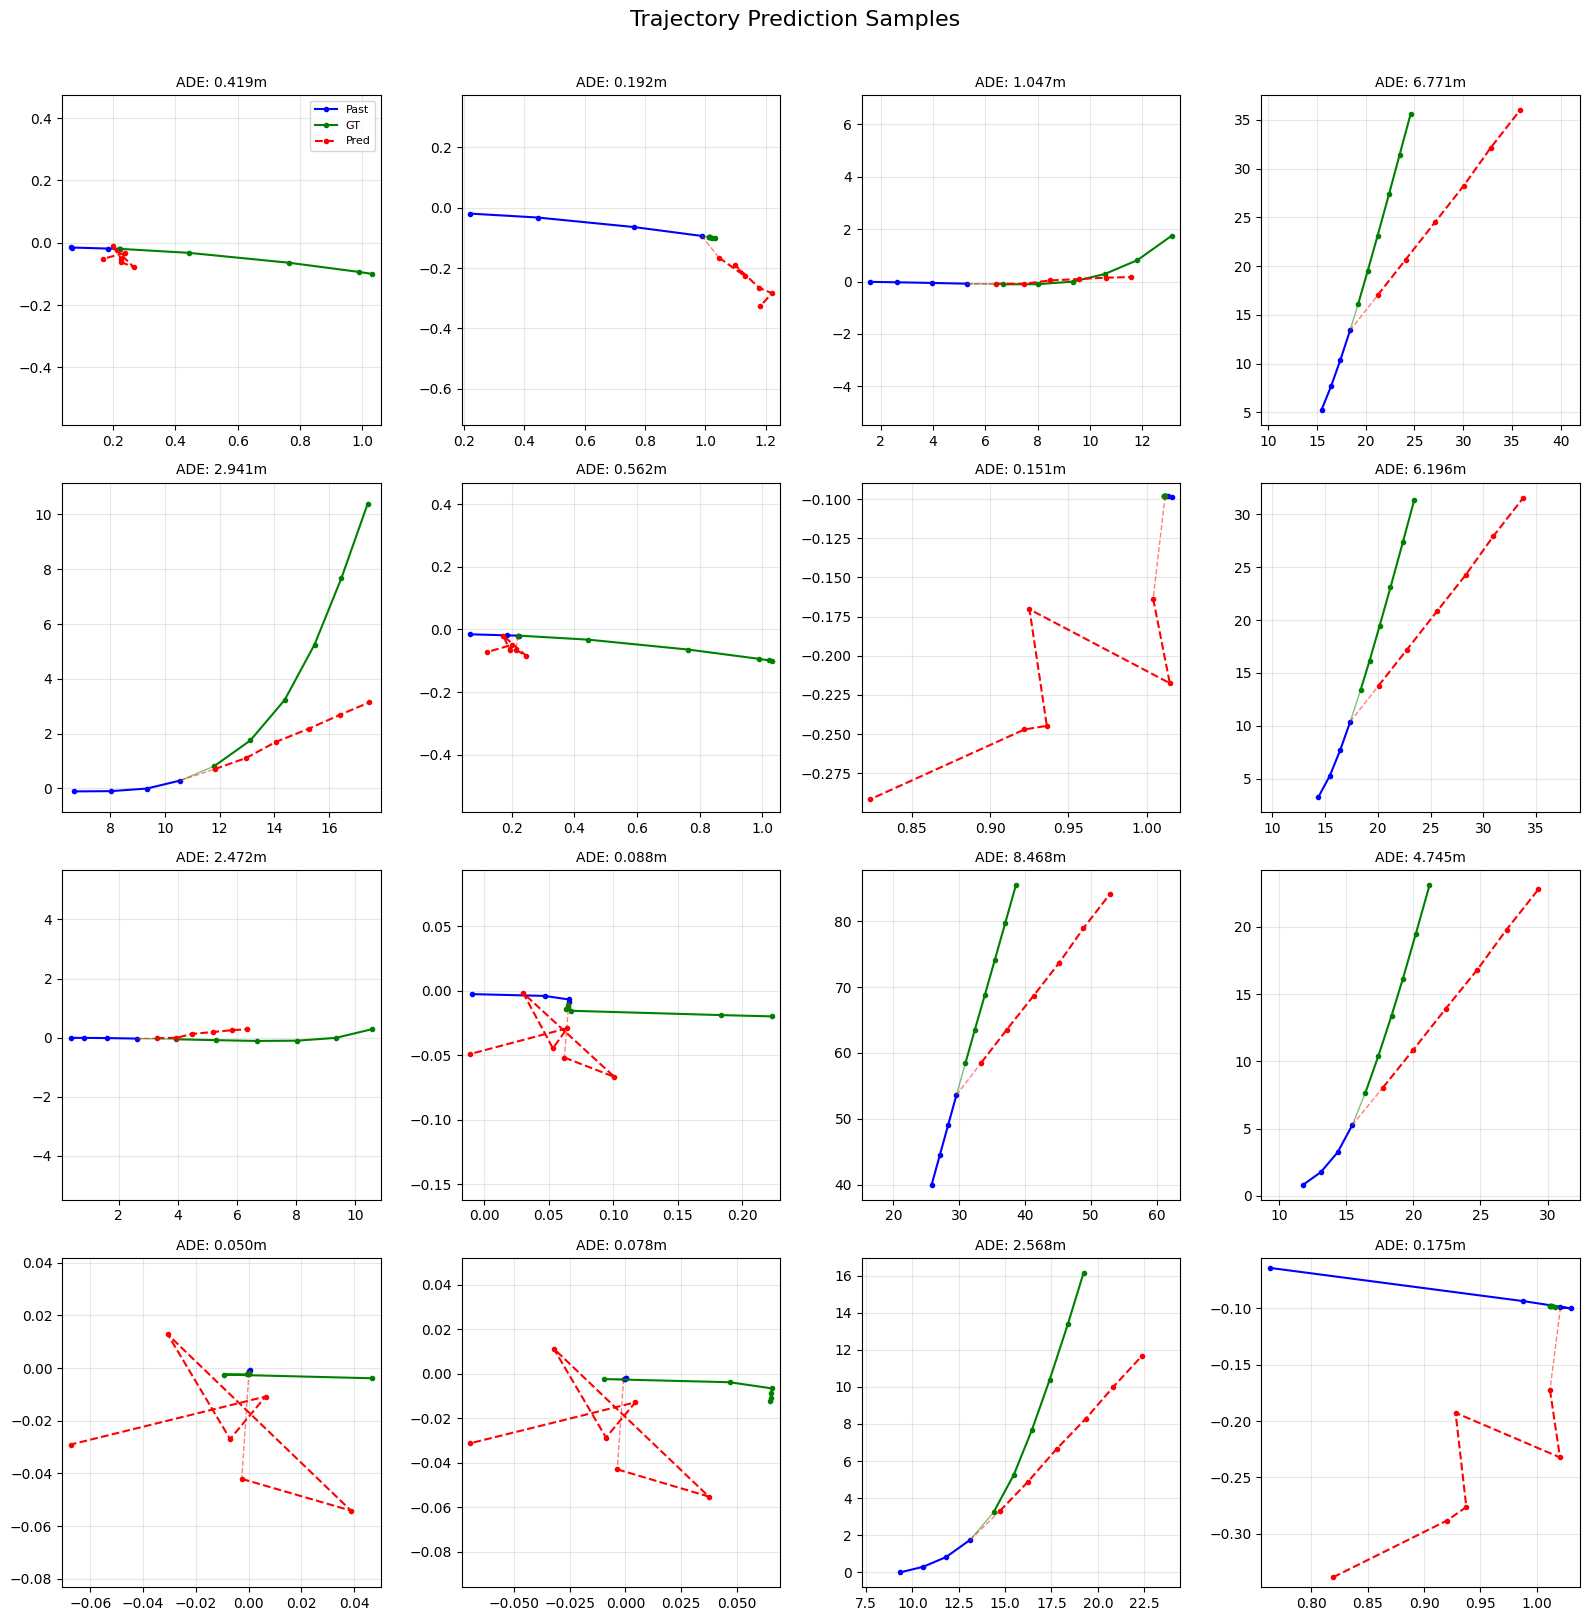

In [25]:
print(" Plotting Trajectory Grid...")
plot_trajectory_grid(model, val_dataset, grid_size=4)

In [26]:
def plot_error_heatmap(model, dataset):
    """Plot XY error heatmap."""
    model.eval()
    all_x_errors = []
    all_y_errors = []

    with torch.no_grad():
        for idx in range(len(dataset)):
            past_feat, last_pos, last_vel, future = dataset[idx]
            past_feat = past_feat.unsqueeze(0).to(DEVICE)
            last_pos_t = last_pos.unsqueeze(0).to(DEVICE)
            last_vel_t = last_vel.unsqueeze(0).to(DEVICE)

            pred = model(past_feat, last_pos_t, last_vel_t)[0].cpu().numpy()
            future_np = future.numpy()

            x_err = pred[:, 0] - future_np[:, 0]
            y_err = pred[:, 1] - future_np[:, 1]

            all_x_errors.extend(x_err)
            all_y_errors.extend(y_err)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # 2D Histogram (Heatmap)
    ax1 = axes[0]
    h = ax1.hist2d(all_x_errors, all_y_errors, bins=50, cmap='hot_r')
    plt.colorbar(h[3], ax=ax1, label='Count')
    ax1.set_xlabel('X Error (m)', fontsize=12)
    ax1.set_ylabel('Y Error (m)', fontsize=12)
    ax1.set_title('Prediction Error Distribution (XY)', fontsize=14)
    ax1.axhline(0, color='white', linestyle='--', alpha=0.5)
    ax1.axvline(0, color='white', linestyle='--', alpha=0.5)

    # X Error distribution
    ax2 = axes[1]
    ax2.hist(all_x_errors, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax2.axvline(np.mean(all_x_errors), color='red', linestyle='--',
                label=f'Mean: {np.mean(all_x_errors):.3f}m')
    ax2.set_xlabel('X Error (m)', fontsize=12)
    ax2.set_ylabel('Count', fontsize=12)
    ax2.set_title('X-axis Error Distribution', fontsize=14)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Y Error distribution
    ax3 = axes[2]
    ax3.hist(all_y_errors, bins=50, color='coral', edgecolor='black', alpha=0.7)
    ax3.axvline(np.mean(all_y_errors), color='red', linestyle='--',
                label=f'Mean: {np.mean(all_y_errors):.3f}m')
    ax3.set_xlabel('Y Error (m)', fontsize=12)
    ax3.set_ylabel('Count', fontsize=12)
    ax3.set_title('Y-axis Error Distribution', fontsize=14)
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n📈 Error Bias Analysis:")
    print(f"  X Error Mean: {np.mean(all_x_errors):.4f} m (bias)")
    print(f"  Y Error Mean: {np.mean(all_y_errors):.4f} m (bias)")
    print(f"  X Error Std:  {np.std(all_x_errors):.4f} m")
    print(f"  Y Error Std:  {np.std(all_y_errors):.4f} m")

 Plotting Error Heatmap...


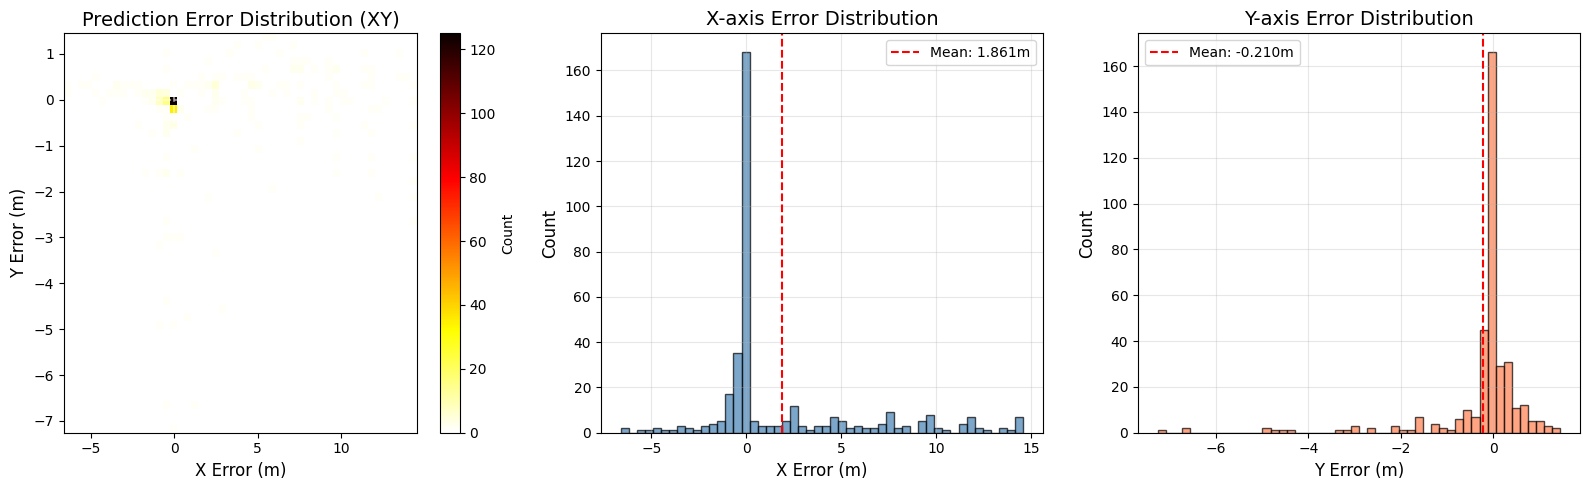


📈 Error Bias Analysis:
  X Error Mean: 1.8605 m (bias)
  Y Error Mean: -0.2104 m (bias)
  X Error Std:  4.2031 m
  Y Error Std:  1.0258 m


In [28]:
print(" Plotting Error Heatmap...")
plot_error_heatmap(model, val_dataset)